In [1]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"
OUT_DIR = BASE_PATH / "outputs" / "densenet201_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

IMG_SIZE = (250, 250)   # আগের মতোই resize
BATCH_SIZE = 4          # GTX 1650 এর জন্য safe
EPOCHS = 20

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

print("Output folder:", OUT_DIR)

Output folder: E:\Thesis\outputs\densenet201_baseline


In [3]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!nvidia-smi

Wed Aug 19 09:42:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   67C    P8              1W /   50W |     132MiB /   4096MiB |     34%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
ham = pd.read_csv(HAM_PATH / "HAM10000_metadata.csv")
pad = pd.read_csv(PAD_PATH / "metadata.csv")

print("HAM shape:", ham.shape)
print("PAD shape:", pad.shape)

HAM shape: (10015, 8)
PAD shape: (2298, 26)


In [6]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

print("HAM class counts:")
print(ham_4["label"].value_counts())

print("\nPAD class counts:")
print(pad_4["label"].value_counts())

HAM class counts:
label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64

PAD class counts:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [7]:
# HAM image_id usually has no extension
ham_4["image_path"] = ham_4["image_id"].apply(lambda x: str(HAM_IMAGE_DIR / f"{x}.jpg"))

# PAD img_id already includes .png
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))

ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print("HAM exists:")
print(ham_4["exists"].value_counts())

print("\nPAD exists:")
print(pad_4["exists"].value_counts())

HAM exists:
exists
True    8659
Name: count, dtype: int64

PAD exists:
exists
True    1871
Name: count, dtype: int64


In [8]:
print("HAM labels:", sorted(ham_4["label"].unique()))
print("PAD labels:", sorted(pad_4["label"].unique()))
print("Same classes:", set(ham_4["label"].unique()) == set(pad_4["label"].unique()))

HAM labels: ['ACK', 'BCC', 'MEL', 'NEV']
PAD labels: ['ACK', 'BCC', 'MEL', 'NEV']
Same classes: True


In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(ham_4, groups=ham_4["lesion_id"]))

train_df = ham_4.iloc[train_idx].copy()
val_df = ham_4.iloc[val_idx].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("PAD test samples:", len(pad_4))

Training samples: 6932
Validation samples: 1727
PAD test samples: 1871


In [12]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

pad_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("PAD samples:", pad_generator.samples)

Found 6932 validated image filenames belonging to 4 classes.
Found 1727 validated image filenames belonging to 4 classes.
Found 1871 validated image filenames belonging to 4 classes.
Train samples: 6932
Val samples: 1727
PAD samples: 1871


In [13]:
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(4, activation="softmax", dtype="float32")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

74836368/74836368 [==============================] - 22s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 250, 250, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 256, 256, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 125, 125, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                            

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
csv_logger = CSVLogger(str(OUT_DIR / "history.csv"), append=False)

checkpoint = ModelCheckpoint(
    filepath=str(OUT_DIR / "best_model.keras"),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[csv_logger, checkpoint, early_stop, reduce_lr]
)

Epoch 1/20
1733/1733 [==============================] - ETA: 0s - loss: 0.5579 - accuracy: 0.8015
Epoch 1: val_accuracy improved from -inf to 0.84598, saving model to E:\Thesis\outputs\densenet201_baseline\best_model.keras
1733/1733 [==============================] - 396s 206ms/step - loss: 0.5579 - accuracy: 0.8015 - val_loss: 0.3777 - val_accuracy: 0.8460 - lr: 0.0010
Epoch 2/20
1733/1733 [==============================] - ETA: 0s - loss: 0.4911 - accuracy: 0.8213
Epoch 2: val_accuracy did not improve from 0.84598
1733/1733 [==============================] - 235s 136ms/step - loss: 0.4911 - accuracy: 0.8213 - val_loss: 0.4433 - val_accuracy: 0.8321 - lr: 0.0010
Epoch 3/20
1733/1733 [==============================] - ETA: 0s - loss: 0.4580 - accuracy: 0.8288
Epoch 3: val_accuracy improved from 0.84598 to 0.84713, saving model to E:\Thesis\outputs\densenet201_baseline\best_model.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1733/1733 [==============

In [19]:
import json
import pickle
import pandas as pd
import numpy as np

# numpy type -> normal Python type
history_clean = {
    k: [float(x) for x in v]
    for k, v in history.history.items()
}

with open(OUT_DIR / "history.json", "w") as f:
    json.dump(history_clean, f)

pd.DataFrame(history.history).to_csv(OUT_DIR / "history_full.csv", index=False)

with open(OUT_DIR / "history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved.")

Training history saved.


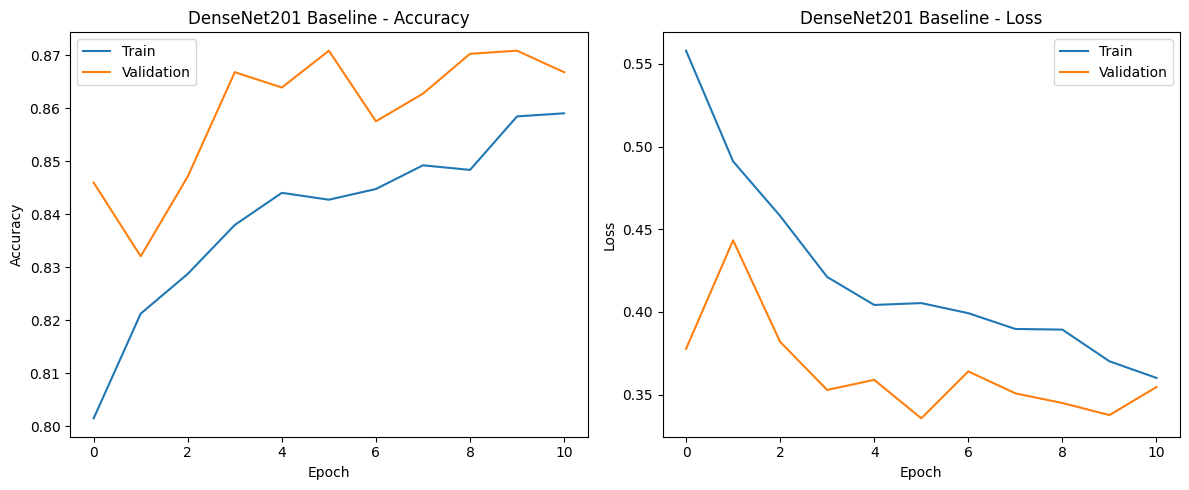

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("DenseNet201 Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("DenseNet201 Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
best_model = tf.keras.models.load_model(OUT_DIR / "best_model.keras")
print("Best model loaded.")

Best model loaded.


In [22]:
pad_loss, pad_accuracy = best_model.evaluate(pad_generator, verbose=1)
print("PAD Accuracy:", pad_accuracy)
print("PAD Loss:", pad_loss)

468/468 [==============================] - 167s 335ms/step - loss: 3.0001 - accuracy: 0.2892
PAD Accuracy: 0.2891501784324646
PAD Loss: 3.0000996589660645


In [23]:
pred_probs = best_model.predict(pad_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = pad_generator.classes

468/468 [==============================] - 104s 200ms/step


In [24]:
acc = accuracy_score(true_classes, pred_classes)
prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.28915018706574025
Precision: 0.29792286744381263
Recall   : 0.34610476349299785
F1 Score : 0.21773694454600206
              precision    recall  f1-score   support

         ACK       0.28      0.03      0.06       730
         BCC       0.68      0.34      0.45       845
         MEL       0.05      0.08      0.06        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.35      0.22      1871
weighted avg       0.44      0.29      0.27      1871



In [25]:
true_onehot = to_categorical(true_classes, num_classes=4)

auc = roc_auc_score(
    true_onehot,
    pred_probs,
    multi_class="ovr",
    average="macro"
)

print("Macro AUC:", auc)

Macro AUC: 0.6664064646292045


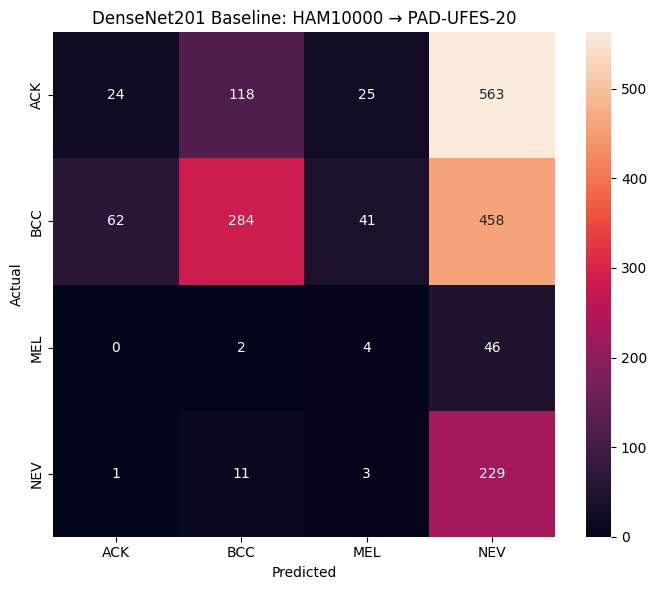

In [26]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet201 Baseline: HAM10000 → PAD-UFES-20")
plt.tight_layout()
plt.show()

In [27]:
results = pd.DataFrame({
    "Experiment": ["DenseNet201 Baseline"],
    "PAD Accuracy": [acc],
    "Macro Precision": [prec],
    "Macro Recall": [rec],
    "Macro F1": [f1],
    "Macro AUC": [auc]
})

print(results)

             Experiment  PAD Accuracy  Macro Precision  Macro Recall  \
0  DenseNet201 Baseline       0.28915         0.297923      0.346105   

   Macro F1  Macro AUC  
0  0.217737   0.666406  
